# GeoIT SR Refiner — 파이프라인 & 베이스라인

위성영상 초해상도 파이프라인 `DINOv3 → RRDBNet → HAT → CycleGAN` 의 **동결 업스트림**을 로드하고,
교체 대상이자 대조군인 **CycleGAN Refiner 베이스라인**을 실행·시각화·평가한다.

- 서버: MS-C931 (GB10) · 프로젝트: `~/geoit_sr_refiner` · 드라이버: `src/` 모듈
- 자산 현황/블로커: **`STATUS.md`** (HAT·DINOv3 가중치, 0.5m GT 대기 중)
- **DEMO 모드**: 실데이터/가중치가 없으면 합성 샘플로 배관만 시연(라벨 명시). 자산 도착 시 그대로 실측 전환.


## 0. 환경 설정

In [1]:
import os, sys, json
import torch

ROOT = os.path.expanduser("~/geoit_sr_refiner")
os.chdir(ROOT)
for p in (ROOT, os.path.join(ROOT, "team_aiduo")):
    if p not in sys.path:
        sys.path.insert(0, p)

import yaml
cfg = yaml.safe_load(open("configs/paths.yaml", encoding="utf-8"))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


torch 2.13.0+cu130 | device: cuda
GPU: NVIDIA GB10


## 1. 자산 점검 — 무엇이 확보/미수령인가

In [2]:
def check_assets(cfg):
    def has(v):
        p = v if os.path.isabs(v) else os.path.join(ROOT, v)
        return os.path.exists(os.path.expanduser(p))
    print("[가중치]")
    for k, v in cfg["weights"].items():
        print(f"  {'✅' if has(v) else '🔴'} {k:16s} {v}")
    print("[데이터]")
    for k, v in cfg["data"].items():
        if isinstance(v, str) and ("root" in k):
            print(f"  {'✅' if has(v) else '🔴'} {k:16s} {v}")

check_assets(cfg)
print("\n🔴 = 미수령/미다운로드. scripts/fetch_assets.md 및 STATUS.md 참조.")


[가중치]
  ✅ rrdb_a2v5b       weights/A2_v5b_rrdbnet_best.pth
  ✅ cyclegan_g_ab    weights/best_G_AB.pth
  🔴 hat              weights/net_g_270000.pth
  🔴 dinov3           weights/classified_DINOv3-Large_best.pth
[데이터]
  ✅ sample_root      data/sr_data_sample
  🔴 paired_root      data/paired_10200
  🔴 hr_domain_root   data/hr_domain
  🔴 sr_output_root   data/sr_output

🔴 = 미수령/미다운로드. scripts/fetch_assets.md 및 STATUS.md 참조.


## 2. 동결 업스트림 로드
`src/upstream.UpstreamPipeline` 은 확보된 모듈만 로드하고, 미수령(HAT·DINOv3)은 `None` 으로 둔다.
가중치 파일이 없으면 랜덤 초기화로 로드되어(경고 출력) DEMO 배관은 계속 진행된다.

In [3]:
from src.upstream import UpstreamPipeline

up = UpstreamPipeline(cfg, device=device)
print("\n[로드 상태]")
print("  RRDB    :", "OK" if up.rrdb is not None else "—")
print("  HAT     :", "OK" if up.hat is not None else "🔴 미수령(None) — SR_Output은 RRDB까지만")
print("  CycleGAN:", "OK" if up.cyclegan is not None else "—")
print("  DINOv3  :", "OK" if up.dinov3 is not None else "🔴 미수령(None) — SC Loss는 VGG 프로토타입")


[RRDB] loaded: A2_v5b_rrdbnet_best.pth
[HAT] WARN weight missing -> None (임계경로, 기업 공유 대기): /home/bh8483/geoit_sr_refiner/weights/net_g_270000.pth
✅ [CycleGen] 가중치 로드 완료: best_G_AB.pth
[DINOv3] WARN weight missing -> None (SC Loss 가이드 대기): /home/bh8483/geoit_sr_refiner/weights/classified_DINOv3-Large_best.pth

[로드 상태]
  RRDB    : OK
  HAT     : 🔴 미수령(None) — SR_Output은 RRDB까지만
  CycleGAN: OK
  DINOv3  : 🔴 미수령(None) — SC Loss는 VGG 프로토타입


## 3. 입력(LR) 준비 & SR_Output 생성
`LR → RRDB → (HAT) → SR_Output`. SR_Output이 refiner의 입력 소스다.
실데이터가 없으면 합성 그라디언트 샘플로 DEMO.

In [4]:
import numpy as np
from src.data_bridge import _list_images, _read_image, _to_tensor

def get_lr_samples(n=3, size=128):
    candidates = [cfg["data"].get("sr_output_root"),
                  os.path.join(cfg["data"].get("sample_root", ""), "test"),
                  cfg["data"].get("sample_root")]
    for c in candidates:
        if not c:
            continue
        d = os.path.join(ROOT, c) if not os.path.isabs(c) else c
        if os.path.isdir(d):
            fs = _list_images(d)[:n]
            if fs:
                print(f"[data] 실샘플 {len(fs)}장 사용: {c}")
                x = torch.stack([_to_tensor(_read_image(f)) for f in fs])
                return x.to(device), False
    print("[data] ⚠️ 실데이터 없음 → 합성 DEMO 샘플 생성")
    base = torch.linspace(0, 1, size).repeat(size, 1)
    demo = torch.stack([torch.stack([base, base.flip(0), base.t()])] * n)
    demo = (demo + 0.08 * torch.rand(n, 3, size, size)).clamp(0, 1)
    return demo.to(device), True

lr, DEMO = get_lr_samples()
with torch.no_grad():
    sr_output = up.sr_output(lr)
print(f"LR {tuple(lr.shape)} → SR_Output {tuple(sr_output.shape)}  |  {'DEMO(합성)' if DEMO else 'REAL'}")


[data] 실샘플 1장 사용: data/sr_data_sample/test
LR (1, 3, 486, 474) → SR_Output (1, 3, 486, 474)  |  REAL


## 4. CycleGAN 베이스라인 리파인 (대조군)
CycleGAN Generator는 Tanh 출력이므로 입력을 `[-1,1]`로, 출력을 `[0,1]`로 환산한다.

In [8]:
import torch.nn.functional as F

@torch.no_grad()
def refine_cyclegan(g, x):
    # CycleGAN 생성기는 4의 배수가 아닌 입력에서 출력 크기가 바뀜 → 패딩 후 크롭으로 크기 보존
    h, w = x.shape[-2:]
    ph, pw = (-h) % 4, (-w) % 4                    # 4의 배수까지 필요한 패딩
    xp = F.pad(x, (0, pw, 0, ph), mode="reflect")
    y = ((g(xp * 2 - 1) + 1) / 2).clamp(0, 1)      # [-1,1] 규약 refine
    return y[..., :h, :w]                          # 원래 크기로 크롭

refined = refine_cyclegan(up.cyclegan, sr_output)
print("SR_Output", tuple(sr_output.shape), "→ Refined", tuple(refined.shape))

SR_Output (1, 3, 486, 474) → Refined (1, 3, 486, 474)


## 5. 시각화 — LR / SR_Output / Refined

saved: runs/baseline_preview.png


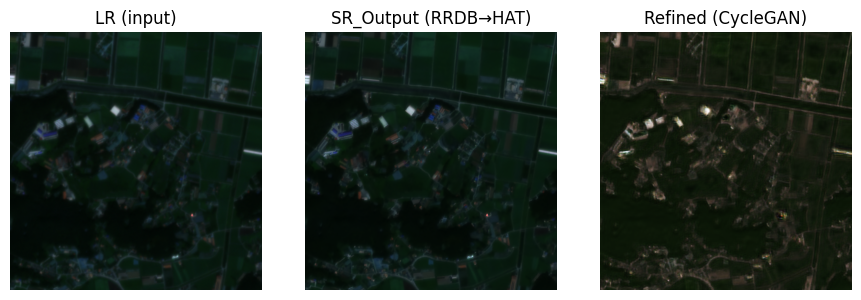

In [10]:
try:
    import matplotlib
    import matplotlib.pyplot as plt

    def to_img(t):
        return t.detach().cpu().clamp(0, 1).numpy().transpose(1, 2, 0)

    n = lr.shape[0]
    fig, ax = plt.subplots(n, 3, figsize=(9, 3 * n))
    ax = ax.reshape(n, 3)
    cols = ["LR (input)", "SR_Output (RRDB→HAT)", "Refined (CycleGAN)"]
    for i in range(n):
        for j, im in enumerate([lr[i], sr_output[i], refined[i]]):
            ax[i, j].imshow(to_img(im)); ax[i, j].axis("off")
            if i == 0:
                ax[i, j].set_title(cols[j])
    plt.tight_layout()
    out = "runs/baseline_preview.png"; os.makedirs("runs", exist_ok=True)
    plt.savefig(out, dpi=110, bbox_inches="tight")
    print("saved:", out)
    plt.show()
except Exception as e:
    print("[viz] skip:", type(e).__name__, e)


## 6. 정량 평가 (Dual-Track)
- **Track1 (paired, GT 존재)**: PSNR / SSIM / LPIPS
- **Track2 (unpaired, GT 없음)**: FID / NIQE

아래는 배관 시연(refined vs SR_Output). 실제 대조군 표는 GT 확보 후 `src.eval_report`로 산정한다.

In [9]:
from src import metrics as M

s, g0 = refined[0], sr_output[0]
dr = cfg["eval"]["psnr_data_range"]
print("[배관 시연 — refined vs SR_Output]")
print("  PSNR :", round(M.psnr(s, g0, dr), 3))
print("  SSIM :", M.ssim(s, g0))
try:
    lp = M.LPIPS(device=device); print("  LPIPS:", lp(s, g0))
except Exception as e:
    print("  LPIPS skip:", e)

print("\n▶ 실제 대조군 평가(GT 확보 후):")
print("  python -m src.baseline_infer --input data/sr_data_sample/test --out runs/baseline_cyclegan")
print("  python -m src.eval_report  --refined runs/baseline_cyclegan --gt data/paired_10200/hr \\")
print("      --hr_domain data/hr_domain --tag baseline_cyclegan")


[배관 시연 — refined vs SR_Output]
  PSNR : 26.975
  SSIM : 0.8167575001716614
[metric] lpips 미설치 → LPIPS skip (No module named 'lpips')
  LPIPS: None

▶ 실제 대조군 평가(GT 확보 후):
  python -m src.baseline_infer --input data/sr_data_sample/test --out runs/baseline_cyclegan
  python -m src.eval_report  --refined runs/baseline_cyclegan --gt data/paired_10200/hr \
      --hr_domain data/hr_domain --tag baseline_cyclegan


In [11]:
import glob, numpy as np
from skimage.metrics import structural_similarity as ssim

# 정답(HR)이 있는 train 4쌍 로드
lr_dir = glob.glob(os.path.join(ROOT, "data/sr_data_sample/**/lr"), recursive=True)[0]
hr_dir = glob.glob(os.path.join(ROOT, "data/sr_data_sample/**/hr"), recursive=True)[0]
hrs = {os.path.splitext(os.path.basename(p))[0]: p for p in _list_images(hr_dir)}
pairs = [(p, hrs[os.path.splitext(os.path.basename(p))[0]])
         for p in _list_images(lr_dir)
         if os.path.splitext(os.path.basename(p))[0] in hrs]

def psnr_np(a, b):
    m = float(((a - b) ** 2).mean()); return float("inf") if m == 0 else 10 * np.log10(1.0 / m)

print(f"{'파일':24s} | {'PSNR_SR':>8} {'SSIM_SR':>8} | {'PSNR_ref':>8} {'SSIM_ref':>8}")
rows = []
for lp, hp in pairs:
    lr = _to_tensor(_read_image(lp)).unsqueeze(0).to(device)
    hr = _to_tensor(_read_image(hp)).unsqueeze(0).to(device)
    if lr.shape[-2:] != hr.shape[-2:]:
        lr = F.interpolate(lr, size=hr.shape[-2:], mode="bicubic", align_corners=False).clamp(0, 1)
    with torch.no_grad():
        sr = up.rrdb(lr)                       # SR_Output
        ref = refine_cyclegan(up.cyclegan, sr) # CycleGAN refine
    A = sr[0].cpu().numpy().transpose(1, 2, 0)
    B = ref[0].cpu().numpy().transpose(1, 2, 0)
    G = hr[0].cpu().numpy().transpose(1, 2, 0)
    r = (os.path.basename(lp), psnr_np(A, G), ssim(A, G, channel_axis=2, data_range=1.0),
         psnr_np(B, G), ssim(B, G, channel_axis=2, data_range=1.0))
    rows.append(r)
    print(f"{r[0][:24]:24s} | {r[1]:8.3f} {r[2]:8.4f} | {r[3]:8.3f} {r[4]:8.4f}")

m = np.array([[r[1], r[2], r[3], r[4]] for r in rows]).mean(0)
print("-" * 64)
print(f"{'평균':24s} | {m[0]:8.3f} {m[1]:8.4f} | {m[2]:8.3f} {m[3]:8.4f}")

파일                       |  PSNR_SR  SSIM_SR | PSNR_ref SSIM_ref
4xSatSR_00057.tif        |   25.258   0.6528 |   16.502   0.5778


/home/bh8483/miniforge3/envs/trellis/lib/python3.10/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


RefRSSRD_00003.tif       |   12.940   0.4539 |   10.365   0.3318
SEN2NAIPv2unet_00003.tif |   24.218   0.7460 |   24.158   0.6618
SEN2VENuS_00023.tif      |   12.137   0.5259 |   17.905   0.5653
----------------------------------------------------------------
평균                       |   18.638   0.5946 |   17.232   0.5342


## 7. 다음 단계
1. **자산 다운로드** — `scripts/fetch_assets.md` (RRDB·CycleGAN 가중치, sr_data_sample)
2. **임계경로 해소** — HAT 가중치(`net_g_270000.pth`)·0.5m GT 기업 요청 (STATUS.md §다음 액션)
3. **Refiner 교체** — `refiners/` 에 CUT/BBDM/UNSB submodule + 어댑터, 총손실에 `+ λ·L_SC(DINOv3)` 결합
4. **대조군 표** — baseline(CycleGAN) vs 제안 3종을 동일 규약으로 Dual-Track 비교
